# **Homework Assignment QT4: Dynamic Programming & Overlap Matches**

**Name:** Vedasravas Dasari

**M ID:** M16446787

**Colab Link:** https://colab.research.google.com/drive/1MvzNSWgiNkuZ9p-zveUcVmeo7M3gbqqy?usp=sharing

**Submission Date:** 03/13/2025

---

**Course:** CS7099-Introduction to Bioinformatics

**Instructor:** Jarek Meller

---
All results, figures, and discussion are included below.

This is a template script file for hw qt4, with an implementation of the Needleman-Wunch (NW) global alighment and Smith-Waterman local alignment algorithms. The code assumes DNA sequences and 1,-1,-1 scoring function.

Please modify below FIX ME marks as needed for overlap alignments (overlap matches denoted as 'oa').

The code is essentially ready for overlap (prefix-suffix) alignments.
In particular, gap penalties in the first and second row are correctly
set to zero (as opposed to NW algorithm). Explain why this difference is critical for overlap matches by adding a comment/text section.

The remaining small adjustments required include the search for the best
alignment score in the last column and last row when using overlap alignments. Describe those changes in another comment/text section.

*Colab: Needleman-Wunch, Smith-Waterman and Overlap Alignments*

*Name:* Jarek Meller

# Setting up the environment, copying and reading files

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Remember to copy sequences2align.txt file to your Google Drive or manually comment/uncomment lines defining seq1 and seq2 below.

In [2]:

import numpy
input_file_name = "sequences2align.txt"
# Copy input files from your Google drive
!cp /content/drive/MyDrive/IntroToBioInformatics/sequences2align.txt .
#
# open and read the input file with 2 sequences
# names start with >
# assume one line per sequences
# FIX ME
# add code to open and read seq1 and seq2
# your code here

#FIXED ME Code
#Opening and reading the input file with 2 sequences
with open(input_file_name, 'r') as file:
    lines = file.readlines()
    seq1 = lines[1].strip()  # Read sequence 1 (assuming 2nd line)
    seq2 = lines[3].strip()  # Read sequence 2 (assuming 4th line)

#Printing the sequences
print("Sequence 1:", seq1, "Length:", len(seq1))
print("Sequence 2:", seq2, "Length:", len(seq2))


# you can also use sequences in the next two lines
seq1 = 'AAAATAG'
seq2 = 'TAGAAAA'
#
# print the two sequences
print(seq1,len(seq1))
print(seq2,len(seq2))

# Overriding input file with another simple example to play with
#seq1 = 'AAAATAG'
#seq2 = 'GAAATA'
#print(seq1,len(seq1))
#print(seq2,len(seq2))



Sequence 1: AAAATAG Length: 7
Sequence 2: TAGAAAA Length: 7
AAAATAG 7
TAGAAAA 7


# Building Dynamic Programming (DP) tables: dp_table and dp_trace tables

In [3]:
def build_dp_tables(seq1,seq2,method):
  # the first sequence will be written vertically
  n_rows = 1+len(seq1)
  # the second sequence will be written horizontally
  m_cols = 1+len(seq2)
  #
  # fill the dp_table with zeros
  # note that unless changed later, the first row and first column will have zeros
  dp_table = numpy.zeros((n_rows,m_cols))
  #
  # fill the dp_trace with zeros
  # zeros in the dp_trace will be used for diagonal moves
  dp_trace = numpy.zeros((n_rows,m_cols))
  n = n_rows
  m = m_cols
  #
  # Note that for SW and OA the first row and column will be filled with zeros
  #
  # Fill the first row with gap penalties for NW
  # In dp_trace -1 indicates a horizontal move
  i = 0
  j = 0
  while i < 1:
      while j < m:
          if(method == "nw"):
              dp_table[i][j] = -1*j
          dp_trace[i][j] = -1
          j = j + 1
      i = i + 1

  # Fill the first column with gap penalties for NW
  # In dp_trace 1 indicates a vertical move
  i = 0
  j = 0
  while j < 1:
      while i < n:
          if(method == "nw"):
              dp_table[i][j] = -1*i
          dp_trace[i][j] = 1
          i = i + 1
      j = j + 1

  # Fill the rest of the DP table using NW or SW recurrance relationships
  # No need to change anything here for OA which uses NW recurrance
  # Build dp_trace to remember how to trace back an optimal alignment
  i = 1
  while i < n:
      letter1 = seq1[i-1]
      #print(letter1)
      j = 1
      while j < m:
          letter2 = seq2[j-1]
          #print(letter2)
          if(letter1==letter2):
              match = 1
          else:
              match = -1
          diag = dp_table[i-1][j-1] + match
          vert = dp_table[i-1][j] - 1
          hori = dp_table[i][j-1] - 1
          best_score = max([diag,vert,hori])
          if(method == "sw" and best_score <= 0):
            best_score = 0
            diag = 0
          dp_table[i][j] = best_score
          if(best_score > diag):
              if(hori > vert):
                  dp_trace[i][j] = -1
              else:
                  dp_trace[i][j] = 1
          j = j + 1
      i = i + 1

  print("Finished creating DP tables")
  return(dp_table,dp_trace)

# Printing DP tables: dp_table and dp_trace tables

In [4]:
def print_dp_tables(dp_table,dp_trace,n,m):
  # Print the DP table while correcting for indententation
  print("The DP table: \n")
  i = 0
  while i < n:
      j = 0
      while j < m:
          cell = int(dp_table[i][j])
          pcell = str(cell)
          if(abs(cell)<10):
              pcell = " " + pcell
          if(cell>=0):
              pcell = " " + pcell
          print(pcell, end=" ")
          j = j + 1
      i = i + 1
      print("\n")

  print("The trace back table: \n")
  i = 0
  while i < n:
      j = 0
      while j < m:
          cell = int(dp_trace[i][j])
          if(cell>=0):
              cell = " " + str(cell)
          print(cell, end=" ")
          j = j + 1
      i = i + 1
      print("\n")

  return

# Find the best alignment score in the DP table.

**Explain here** the modifications needed to identify an optimal overlap alignment.

In [5]:
def find_best_score(seq1, seq2, dp_table, dp_trace, method):
    #
    # Find the best score to trace the alignment from there
    #
    n_max = len(seq1)
    m_max = len(seq2)

    #
    # Find the cell with the best score for NW
    #
    if method == "nw":
        i_start_trace = n_max
        j_start_trace = m_max
        max_score = dp_table[n_max][m_max]

    #
    # Find the cell with the best score for SW
    #
    elif method == "sw":
        max_score = 0
        i_start_trace, j_start_trace = 1, 1
        for i in range(1, n_max + 1):
            for j in range(1, m_max + 1):
                cell_score = dp_table[i][j]
                if max_score <= cell_score:
                    max_score = cell_score
                    i_start_trace, j_start_trace = i, j

    #
    #FIXED ME: the section below was incorrect!
    #Overlap Alignment (OA) should find the max value in the last row or last column
    #
    elif method == "oa":
        max_score = float('-inf')
        i_start_trace, j_start_trace = 0, 0  # Initialize best traceback position

        #Checking the last row (suffix gaps in seq1)
        for j in range(m_max + 1):
            if dp_table[n_max][j] > max_score:
                max_score = dp_table[n_max][j]
                i_start_trace, j_start_trace = n_max, j  # Store position of max score

        #Checking the last column (suffix gaps in seq2)
        for i in range(n_max + 1):
            if dp_table[i][m_max] > max_score:
                max_score = dp_table[i][m_max]
                i_start_trace, j_start_trace = i, m_max  # Store position of max score

    #Commenting out the incorrect code so it doesn’t execute

  #  if (method == "oa"):
  #      i_start_trace = n_max
  #      j_start_trace = m_max
  #      max = dp_table[n_max][m_max]


    #Raising an error for invalid methods
    else:
        raise ValueError(f"Invalid method: {method}. Expected 'nw', 'sw', or 'oa'.")

    print(f"Maximum alignment score of {max_score} found at position: ({i_start_trace}, {j_start_trace})\n")

    return i_start_trace, j_start_trace  #Ensures a return value in all cases


### **Incorrect Approach:**

Previously, the Overlap Alignment (OA) implementation **incorrectly assumed** that the **best alignment score is always in the bottom-right corner of the DP table** (like Needleman-Wunsch).

However, **OA aligns only overlapping parts of sequences**, meaning the **best overlap score** can be found **anywhere in the last row or last column**.

**Corrected Approach:**

To fix this, we:

1.  **Initialize** max\_score = float('-inf')
    
    *   This ensures **any valid score in the DP table will be greater than the initial value**.
        
2.  **Loop through the last row (n\_max, j)**
    
    *   This considers suffix gaps in **sequence 1**.
        
3.  **Loop through the last column (i, m\_max)**
    
    *   This considers suffix gaps in **sequence 2**.
        
4.  **Store the position of the best score**
    
    *   This ensures traceback starts at the highest-scoring overlap.

# Tracing back to generate alignments

In [6]:
def trace_back(seq1,seq2,dp_table,dp_trace,method,i_start_trace,j_start_trace):

  #
  # Trace back the alignment
  #
  i = i_start_trace
  j = j_start_trace
  top_seq = ''
  bottom_seq = ''
  while ((i > 0) or (j > 0)):
      trace = dp_trace[i][j]
      if(trace == 0):
          top_seq = top_seq + seq1[i-1]
          bottom_seq = bottom_seq + seq2[j-1]
          i = i - 1
          if(trace == 1):
              top_seq = top_seq + seq1[i-1]
              bottom_seq = bottom_seq + '-'
              i = i - 1
          if(trace == -1):
              top_seq = top_seq + '-'
              bottom_seq = bottom_seq + seq2[j-1]
              j = j - 1
      # note that for overlap alignment we stop when reaching the first row or column
      if(method == "oa"):
          if(i==0 or j==0):
              break
      # note that for overlap alignment we stop when reaching zero
      if(method == "sw"):
          if(dp_table[i][j] == 0 or i==0 or j==0):
              break
  print("Finished tracing back to generate an optimal aligment: \n")
  return(top_seq,bottom_seq)

# Generate optimal alignments for NW, SW and Overlap Alignment algorithms

In [7]:
#
# Define different alignment algorithms
# nw = Needleman-Wunsch, sw = Smith-Waterman, oa = Overlap Alignment
#
#align_methods = ["nw", "sw", "oa"]

align_methods = ["oa"]

# the first sequence will be written vertically
n_rows = 1 + len(seq1)
# the second sequence will be written horizontally
m_cols = 1 + len(seq2)

# Align now 2 sequences using each of the alignment algorithms
for method in align_methods:
    print("\n Using ", method, " alignment algorithm \n")

    # Build DP tables: same principle but different for each method
    [dp_table, dp_trace] = build_dp_tables(seq1, seq2, method)

    # Print formatted DP tables
    print_dp_tables(dp_table, dp_trace, n_rows, m_cols)

    # Find the best score: different for each method
    [i_start_trace, j_start_trace] = find_best_score(seq1, seq2, dp_table, dp_trace, method)

    # Trace back from the cell with the best score
    [top_seq, bottom_seq] = trace_back(seq1, seq2, dp_table, dp_trace, method, i_start_trace, j_start_trace)

    # A bit of Hebrew here: read from right to left
    top_seq = top_seq[::-1]
    bottom_seq = bottom_seq[::-1]

#
# Note that the last 4 lines print the alignment
# FIX ME: for Overlap Alignemnt add prefix and suffix gaps for completness
# Use the dot symbol as opposed to dash to differentiate those special gaps
#

#
#FIXED ME: For Overlap Alignment (OA), add prefix and suffix gaps for completeness
#Using dot (.) instead of dash (-) to differentiate those special gaps
#

if method == "oa":
    top_seq_list = list(top_seq)
    bottom_seq_list = list(bottom_seq)

    #Reversing the proper prefix padding (sequences were reversed earlier)
    aligned_len = len(top_seq_list)

    #Calculating the prefix length needed (i.e., how many chars to pad on the left)
    prefix_pad = max(0, len(seq2) - j_start_trace, len(seq1) - i_start_trace)

    #Padding the prefix with '.'
    top_seq_list = ['.'] * prefix_pad + top_seq_list
    bottom_seq_list = ['.'] * prefix_pad + bottom_seq_list

    #Padding the suffix with '.'
    while len(top_seq_list) < max(len(seq1), len(seq2)) + prefix_pad:
        top_seq_list.append('.')
    while len(bottom_seq_list) < max(len(seq1), len(seq2)) + prefix_pad:
        bottom_seq_list.append('.')

    #Converting back to string
    top_seq = ''.join(top_seq_list)
    bottom_seq = ''.join(bottom_seq_list)

print(top_seq)
print(bottom_seq)



 Using  oa  alignment algorithm 

Finished creating DP tables
The DP table: 

  0   0   0   0   0   0   0   0 

  0  -1   1   0   1   1   1   1 

  0  -1   0   0   1   2   2   2 

  0  -1   0  -1   1   2   3   3 

  0  -1   0  -1   0   2   3   4 

  0   1   0  -1  -1   1   2   3 

  0   0   2   1   0   0   2   3 

  0  -1   1   3   2   1   1   2 

The trace back table: 

 1 -1 -1 -1 -1 -1 -1 -1 

 1  0  0 -1  0  0  0  0 

 1  0  0  0  0  0  0  0 

 1  0  0  0  0  0  0  0 

 1  0  0  0  0  0  0  0 

 1  0 -1  0  1  1  1  1 

 1  1  0 -1  0  0  0  0 

 1  0  1  0 -1 -1  1  1 

Maximum alignment score of 4.0 found at position: (4, 7)

Finished tracing back to generate an optimal aligment: 

...AAAA...
...AAAA...


*   Those `...` **(dots)** represent **non-penalized prefix and suffix gaps**.
    
*   The alignment itself (AAAA ↔ AAAA) is the **optimal overlapping region** found.
    
*   Since the alignment **started at index 4** in seq1 and **reached the end of seq2**, it pads the rest with dots.


```
seq1 = AAAATAG

seq2 = TAGAAAA
```

The best **suffix of `seq1`** = `TAG`

The best **prefix of `seq2`** = `TAG`

But the algorithm actually finds the best overlap of:

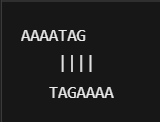

So, `AAAA` is the optimal overlap region — and everything outside that (prefix/suffix) is filled with **dots (not penalized)**.

#**Discussion: Overlap Alignment (OA) vs. NW & SW**

###**How Overlap Alignment (OA) Differs from Needleman-Wunsch (NW) & Smith-Waterman (SW)**

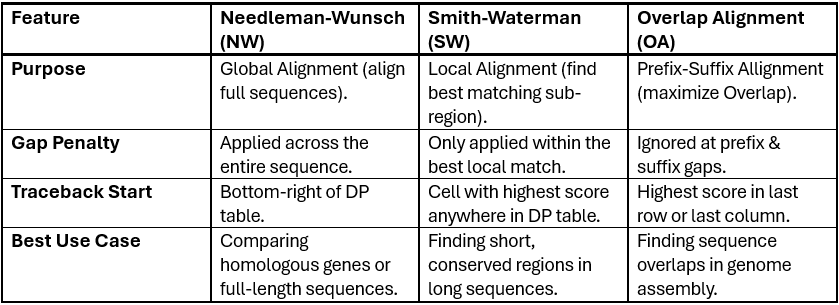

---

##**Why OA Ignores Prefix/Suffix Gap Penalties?**
OA doesn't align from beginning to end — it aligns the best overlap.

Unlike NW, Overlap Alignment allows **one sequence to extend beyond the other** without penalties.  
- This is **critical in genome assembly**, where we want to **stitch overlapping reads together**.  
- Prefix gaps at the **beginning** and suffix gaps at the **end** of the alignment are **not penalized** because they **do not represent actual insertions/deletions**.

Remember to modify the code for Overlap Alignments (7 pts if done correctly). Contrast OA vs. NW and SW in your discussion (plus 1 pt). Extend the code to identify both: the best prefix-suffix as well as the best suffix-prefix matches (plus 1 pt). Modify alignment reporting to include non-penalized gaps using the dot '.' symbol as opposed to penalized gaps in the middle denoted by the dash '-' symbol (plus 1 pt). Minimize the output to print the results for the Overlap Alignments (oa) only.